# Four ways to measure rain over New York City

This project compares four sensors on the same storms:

| sensor | what it measures | source | in FieldSense |
|---|---|---|---|
| **NYC Mesh links** | received signal level of 103 community-network microwave sublinks, 1 min | OpenMesh, [doi:10.5281/zenodo.15287692](https://doi.org/10.5281/zenodo.15287692) | `core.opensense.openmesh` |
| **PWS** | rain in 37 Weather Underground personal stations, ~5 min | OpenMesh PWS, [doi:10.5281/zenodo.17508286](https://doi.org/10.5281/zenodo.17508286) | `core.opensense.openmesh` |
| **MRMS radar** | gauge-corrected radar rainfall, 0.01° grid, hourly | NOAA/NSSL, AWS `noaa-mrms-pds` | `core.radar.mrms` |
| **ASOS** | official NWS airport gauges and present weather (rain/snow/mix) | Iowa Environmental Mesonet | `core.asos` |

The links are the sensor being tested. MRMS is the reference map, the PWS are a second, denser
but noisier reference, and ASOS is the independent check that never enters a map.

This notebook opens each source for one storm: the 9-10 January 2024 rainstorm.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nyc_rain_maps import plots

from core.asos import fetch_asos, hourly_precip, hourly_ptype
from core.geo import NYC, OPENMESH
from core.opensense import openmesh as om
from core.radar.mrms import hourly_rainfall

START, END = ("2024-01-09 16:00", "2024-01-10 11:00")

## The links

The full OpenMesh record (29 Oct 2023 - 1 Jul 2024) downloads from Zenodo on first use,
14 MB. A *link set* is `rsl(link, time)` with one row per sublink, labelled `"<cml_id>/<sublink>"`.
Only received power is published: path loss is `-RSL` up to a constant.

In [2]:
table = om.sublinks_table()
bands = pd.cut(table.frequency, [0, 10, 30, 100], labels=["5-6 GHz", "24 GHz", "58-69 GHz"])
print(f"{len(table)} sublinks on {table.cml_id.nunique()} links, "
      f"{table.length.min():.2f}-{table.length.max():.2f} km")
print(bands.value_counts().to_string())
table.head()

103 sublinks on 75 links, 0.02-6.94 km
frequency
5-6 GHz      59
58-69 GHz    36
24 GHz        8


,cml_id,sublink_id,frequency,length,polarization,site_0_lat,site_0_lon,site_1_lat,site_1_lon,availability,mid_lat,mid_lon
link,,,,,,,,,,,,
1/sublink_1,1,sublink_1,68.040,2.178100,v,40.696095,-73.939751,40.686199,-73.917503,0.973541,40.691147,-73.928627
1/sublink_2,1,sublink_2,68.040,2.178100,v,40.696095,-73.939751,40.686199,-73.917503,0.960671,40.691147,-73.928627
1/sublink_3,1,sublink_3,5.765,2.178100,v,40.696095,-73.939751,40.686199,-73.917503,0.881569,40.691147,-73.928627
2/sublink_1,2,sublink_1,5.545,2.954633,v,40.657784,-74.004845,40.682995,-73.993790,0.878631,40.670389,-73.999317
2/sublink_2,2,sublink_2,24.100,2.954633,v,40.657784,-74.004845,40.682995,-73.993790,0.861411,40.670389,-73.999317


In [3]:
links = om.load_links(START, END)
pws = om.load_pws(START, END)
print("links:", dict(links.sizes), " PWS:", dict(pws.sizes))

links: {'link': 103, 'time': 1141}  PWS: {'time': 229, 'station': 37}


## Radar and airport gauges

MRMS hourly QPE (Pass 2, gauge-corrected) is fetched from NOAA's AWS bucket, decoded and cropped
to New York, and cached by day: a crop is a few kB, so the whole record is a few MB. ASOS
reports come from the Iowa Environmental Mesonet.

In [4]:
qpe = hourly_rainfall(START, END, NYC)
asos = fetch_asos(START, END)
asos_mm = hourly_precip(asos)
print("MRMS:", dict(qpe.sizes), " ASOS stations:", sorted(asos.station.unique()))
print("present weather, station-hours:", hourly_ptype(asos).stack().value_counts().to_dict())

MRMS: {'time': 19, 'lat': 45, 'lon': 59}  ASOS stations: ['EWR', 'JFK', 'LGA', 'NYC']
present weather, station-hours: {'rain': 62, 'none': 14}


## All four on one map

Event total from the radar, the link paths, the PWS stations sized by their event total, and
the ASOS stations. The link network covers Brooklyn and lower Manhattan only.

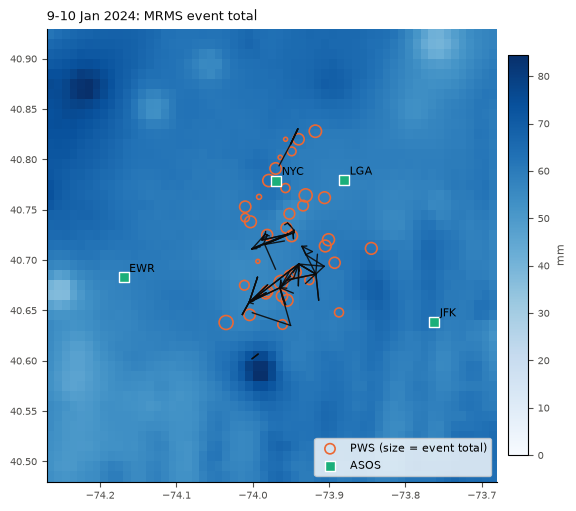

In [5]:
total = qpe.sum("time", min_count=1)
fig, ax = plt.subplots(figsize=(7, 6.5))
plots.plot_field(total, ax, title="9-10 Jan 2024: MRMS event total", label="mm")
plots.draw_links(ax, links, lw=1.0)
pws_tot = pws.rain.sum("time", min_count=1)
ax.scatter(pws.lon, pws.lat, s=8 + pws_tot.fillna(0), facecolor="none", edgecolor="#eb6834",
           lw=1.2, label="PWS (size = event total)")
st = asos.groupby("station")[["lat", "lon"]].first()
ax.scatter(st.lon, st.lat, marker="s", s=60, color="#1baf7a", edgecolor="white", label="ASOS")
for name, r in st.iterrows():
    ax.annotate(name, (r.lon, r.lat), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.legend(loc="lower right", fontsize=8);

## The same storm through each sensor

Hourly rain: radar averaged over the city, the PWS median, each airport gauge, and the
received level of one link (a deeper dip is more rain on its path).

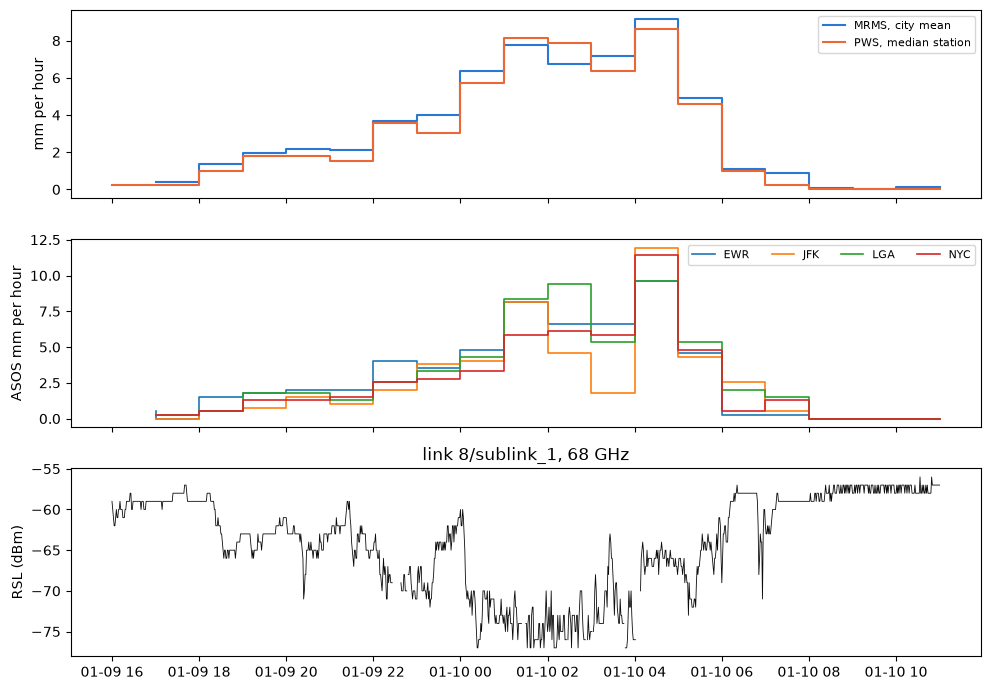

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
# plain matplotlib throughout: pandas' own .plot() puts dates on a different axis scale
radar = qpe.mean(("lat", "lon"))
axes[0].step(radar.time, radar, where="pre", color="#2a78d6", label="MRMS, city mean")
pws_h = pws.rain.resample(time="1h", label="right", closed="right").sum(min_count=6).median("station")
axes[0].step(pws_h.time, pws_h, where="pre", color="#eb6834", label="PWS, median station")
axes[0].set_ylabel("mm per hour")
axes[0].legend(fontsize=8)
window = asos_mm.loc[pd.Timestamp(START):pd.Timestamp(END)]
for station in window.columns:
    axes[1].step(window.index, window[station], where="pre", lw=1.2, label=station)
axes[1].set_ylabel("ASOS mm per hour")
axes[1].legend(fontsize=8, ncol=4)
rsl = links.rsl.sel(link="8/sublink_1")
axes[2].plot(rsl.time, rsl, color="#0b0b0b", lw=0.6)
axes[2].set(ylabel="RSL (dBm)", title="link 8/sublink_1, 68 GHz")
fig.tight_layout()

Next: `02_events_and_links.ipynb` - which storms to study, and which links to trust.